# 📊 FinDataMining
Notebook 02: **Transformación de Datos**

---

## Preliminares

In [1]:
import pandas as pd
import numpy as np
from src.config import data_folder
%load_ext autoreload
%autoreload 2
from src.clean_transform import corregir_anomalias
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")

# Se asegura el ordenamiento por fecha
df = df.sort_values(by='Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11389 entries, 0 to 11388
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         11389 non-null  datetime64[ns]
 1   Ticker                       11389 non-null  object        
 2   Close                        11389 non-null  float64       
 3   Open                         11389 non-null  float64       
 4   Volume                       11389 non-null  float64       
 5   DateAdded                    6720 non-null   object        
 6   Sector                       11367 non-null  object        
 7   Industry                     11367 non-null  object        
 8   TotalRevenue                 11389 non-null  float64       
 9   GrossProfit                  10536 non-null  float64       
 10  OperatingIncome              11389 non-null  float64       
 11  NetIncome                    11389 non-nu

## Limpieza de Datos

In [3]:
# Limpiar cadenas en Industry y Sector: 
# sin espacios, primer letra en mayuscula y reemplaza el simbolo '&' por 'And'
df['Industry'] = df['Industry'].apply(limpiar_cadenas)
df['Sector'] = df['Sector'].apply(limpiar_cadenas)

# Ver cambios
df[['Industry', 'Sector']].head()

,Industry,Sector
0,Home Improvement Retail,Consumer Cyclical
1,Apparel Retail,Consumer Cyclical
2,Discount Stores,Consumer Defensive
3,Apparel Retail,Consumer Cyclical
4,Software Application,Technology


* Se convierten Sector y Industry a variable tipo *category*:

In [4]:
df['Sector'] = df['Sector'].astype('category')
df['Industry'] = df['Industry'].astype('category')

# Valores unicos en Sector
df['Sector'].value_counts()

Sector
Consumer Cyclical         2330
Industrials               2223
Technology                1832
Healthcare                1140
Financial Services         901
Consumer Defensive         861
Basic Materials            614
Energy                     583
Communication Services     426
Real Estate                251
Utilities                  206
Name: count, dtype: int64

In [5]:
# Valores unicos en Industry
df['Industry'].value_counts()

Industry
Specialty Industrial Machinery           362
Semiconductors                           298
Software Application                     288
Information Technology Services          273
Engineering And Construction             263
                                        ... 
Reit Industrial                           23
Solar                                     22
Luxury Goods                              22
Utilities Independent Power Producers     22
Lumber And Wood Production                21
Name: count, Length: 116, dtype: int64

* Para mejorar la visualización de los datos, se expresan las columnas financieras y volumen en millones:

In [6]:
df = columnas_en_millones(df)

### Corrección de anomalías

#### Error de importes en Balance General
Se analiza el siguiente registro, el cual muestra valores extremadamente elevados en el Balance:

In [7]:
# Caso 1: Error de importes en el Galance General
condicion_1 = df[(df['Ticker'] == 'IIIN') & (df['Date'] == '2021-12-01')]

# Mostrar el registro
print(condicion_1.T)

                                            2498
Date                         2021-12-01 00:00:00
Ticker                                      IIIN
Close                                  28.253126
Open                                   31.382212
Volume                                    7.3179
DateAdded                                   None
Sector                               Industrials
Industry                       Metal Fabrication
TotalRevenue                             171.258
GrossProfit                               39.919
OperatingIncome                           32.598
NetIncome                                 25.152
EBITDA                                       NaN
BasicAverageShares                        19.344
CashAndCashEquivalents                   89884.0
CurrentDebt                                  NaN
LongTermDebt                                 NaN
TotalDebt                                    NaN
StockholdersEquity                      302038.0
TotalAssets         

* Se observa una desconexión en los valores del Balance General, están multiplicados por 1.000.
* El caso se detecto ya que arrojaba valores extremos en las métricas.

Se corrigirá dividiendo las columnas afectadas por 1.000.

#### Anomalías de signo: 

Las siguientes variables no pueden ser negativas:
* `TotalRevenue`
* `CurrentDebt`
* `LongTermDebt`
* `DepreciationAndAmortization`

In [8]:
# Caso 2:  TotalRevenue negativo
condicion_2 = df['TotalRevenue'] < 0

# Mostrar los registros
cols_a_visualizar_2 = ['Ticker', 'Date', 'TotalRevenue', 'OperatingIncome']
anomalias = df.loc[condicion_2, cols_a_visualizar_2]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalRevenue  OperatingIncome
587    AVNT 2021-03-01     -30.20000       -12.700000
754     ALB 2021-03-01   -1790.31392      -114.758843
791     XPO 2021-03-01   -1093.00000        14.000000
2099    EMR 2021-12-01    -357.00000      -206.000000
2595    XPO 2022-03-01   -2243.00000      -189.000000
2673   FTNT 2022-03-01   -1415.00000       213.700000
2919    BHF 2022-03-01    -150.00000      2266.000000
4110      J 2022-12-01   -1258.70300       -69.426000
4518    BAX 2023-03-01    -704.00000      -285.000000
4642    BHF 2023-03-01    -127.00000        40.000000
4835     GE 2023-03-01  -12134.00000      4010.000000
4950    CNA 2023-03-01   -3542.00000     -4648.000000
5055    NGL 2023-06-01    -967.05000        65.932000
5523    WDC 2023-09-01   -3391.00000        93.000000
6186   OTIS 2023-12-01   -3543.00000      -516.000000
6345      J 2023-12-01   -1212.28200      -120.924000
6482   NDAQ 2024-03-01    -522.00000       481.000000
6592    FTV 2024-03-01    -5

* No se puede concluir que se traten de alteraciones de signo en el parseo de datos de simFin. Se observa en 2 casos que el valor absoluto de `TotalRevenue` es mayor que `OperatingIncome`, es imposible que los resultados sean mayores que las ventas.

Se opta por asignar todos estos valores anómalos a NaN.

#### Casos de deuda negativa: 
Se calcula el Pasivo Implícito, que surge de aplicar la ecuación contable fundamental `Activo` = `Pasivo` + `Patrimonio Neto`

In [9]:
# Caso 3:  Deuda negativa
condicion_3 = (df['CurrentDebt'] < 0) | (df['LongTermDebt'] < 0)

# Calcular el Pasivo Implícito
df['PasivoImplicito'] = df['TotalAssets'] - df['StockholdersEquity']

# Ver registros
cols_a_visualizar_3 = ['Ticker', 'Date', 'TotalDebt', 'CurrentDebt', 'LongTermDebt', 'PasivoImplicito']
anomalias = df.loc[condicion_3, cols_a_visualizar_3]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalDebt  CurrentDebt  LongTermDebt  PasivoImplicito
3948    IEP 2022-09-01        NaN     -746.000      7134.000        15991.000
4027    IEP 2022-12-01        NaN     -745.000      7127.000        16908.000
6494   STLD 2024-03-01        NaN      459.987     -3286.537          171.287
7445   STLD 2024-06-01        NaN      425.696     -3570.028         -203.283
8422   STLD 2024-12-01        NaN      882.013     -3997.348         -218.698
8592    TXN 2025-03-01        NaN      750.000    -28049.000       -22289.000
Cantidad de casos: 6


* Se observa que la ecuación contable fundamental no se cumple. 

Se decide eliminar estos registros "tóxicos" del dataset.

#### Negativos en `DepreciationAndAmortization`: 

Se analizan los casos considerando la ecuación `EBITDA` = `OperatingIncome` + `DepreciationAndAmortization`, separando los registros según provengan de `yfinance` o de `simFin`:

In [10]:
# Caso 4:  Depreciación y Amortización negativa de yfinance
condicion_4 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='yfinance')

# Ver registros
cols_a_visualizar_4 = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome', 'FinancialsSource']
anomalias = df.loc[condicion_4, cols_a_visualizar_4]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
11285    GME 2026-06-01                         -0.3   144.9            144.9   

      FinancialsSource  
11285         yfinance  
Cantidad de casos: 1


* En este caso se observa que el valor implicito de `DepreciationAndAmortization` es igual a cero (EBITDA = OperatingIncome).
El valor de -0.3 pudo haberse tratado de un pequeño "ajuste contable", $300.000 dólares para una compañia del tamaño de `GameStop` es contablemente irrelevante. 

Se reemplazará el valor por cero.

In [11]:
# # Caso 5: Depreciación y Amortización negativa de simFin
condicion_5 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='simFin')

# Ver registros
anomalias = df.loc[condicion_5, cols_a_visualizar_4] # mismas columnas que el caso anterior
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
0        HD 2020-09-01                     -519.000     NaN         6067.000   
3      BURL 2020-09-01                      -54.404     NaN          -81.224   
6       TGT 2020-09-01                     -542.000     NaN         2300.000   
7       ADI 2020-09-01                     -107.077     NaN          450.954   
8        DY 2020-09-01                      -44.129     NaN           54.482   
...     ...        ...                          ...     ...              ...   
9679   ADBE 2025-09-01                      -41.000     NaN         2109.000   
9726   ORCL 2025-09-01                     -544.000     NaN         5191.000   
9819    HPE 2025-09-01                      -37.000     NaN          294.000   
9825   CIEN 2025-09-01                       -6.545     NaN           34.790   
9845   LULU 2025-09-01                       -1.630     NaN          438.625   

     FinancialsSource  
0              

* `simFin` utiliza signo negativo para esta columna, lo cual es incorrecto. 

Dichos valores serán convertidos a positivos.

In [12]:
# Se aplican los cambios mencionados
df_clean = corregir_anomalias(df)

# Se elimina la columna calculada 'PasivoImplicito'
df_clean = df_clean.drop(columns= 'PasivoImplicito')

## Tratamiento Inicial de Missings

In [13]:
# Ver incidencia de missings
mostrar_missings(df_clean)

TotalDebt                      0.835720
FreeCashFlow                   0.833787
EBITDA                         0.833787
DepreciationAndAmortization    0.462883
DateAdded                      0.409997
CurrentDebt                    0.237811
GrossProfit                    0.074936
LongTermDebt                   0.056400
CurrentAssets                  0.048406
CurrentLiabilities             0.048142
CapitalExpenditure             0.026882
BasicAverageShares             0.004129
CashAndCashEquivalents         0.004041
FinancingCashFlow              0.003250
OperatingCashFlow              0.002636
InvestingCashFlow              0.002196
TotalRevenue                   0.002196
Industry                       0.001933
Sector                         0.001933
StockholdersEquity             0.001757
TotalAssets                    0.001493
NetIncome                      0.000000
OperatingIncome                0.000000
Open                           0.000000
Date                           0.000000


In [14]:
sector_missing = df_clean.loc[df_clean['Sector'].isna(),['Date', 'Close', 'Ticker', 'Sector', 'Industry', 'FinancialsSource']]
print(sector_missing)
print("Cantidad de casos:", len(sector_missing))

            Date       Close Ticker Sector Industry FinancialsSource
306   2020-12-01  158.368118   MKSI    NaN      NaN           simFin
858   2021-03-01  181.001816   MKSI    NaN      NaN           simFin
995   2021-06-01  141.695450   MKSI    NaN      NaN           simFin
1864  2021-09-01  146.713669   MKSI    NaN      NaN           simFin
2404  2021-12-01  145.406799   MKSI    NaN      NaN           simFin
2659  2022-03-01  119.417831   MKSI    NaN      NaN           simFin
3186  2022-06-01   96.499100   MKSI    NaN      NaN           simFin
3633  2022-09-01   81.385635   MKSI    NaN      NaN           simFin
4477  2022-12-01   94.324905   MKSI    NaN      NaN           simFin
5104  2023-06-01   97.998787   MKSI    NaN      NaN           simFin
5570  2023-09-01   80.902534   MKSI    NaN      NaN           simFin
6063  2023-12-01  120.651382   MKSI    NaN      NaN           simFin
6818  2024-03-01  124.637436   MKSI    NaN      NaN           simFin
7348  2024-06-01  117.592255   MKS

In [15]:
# Se imputa manualmente el caso encontrado
condicion = df_clean['Ticker'] == 'MKSI'
df_clean.loc[condicion, 'Sector'] = 'Technology'
df_clean.loc[condicion, 'Industry'] = 'Scientific And Technical Instruments'

* Se imputan parte de los NaNs en Variables Financieras antes de calcular métricas, 
mediante las relaciones contables entre ellas:

In [16]:
df_fin_imputed = imputar_equivalencias_financieras(df_clean)
mostrar_missings(df_fin_imputed)

DateAdded                      0.409997
TotalDebt                      0.208820
CurrentDebt                    0.207590
GrossProfit                    0.074936
LongTermDebt                   0.054731
CurrentAssets                  0.048406
CurrentLiabilities             0.048142
CapitalExpenditure             0.026882
FreeCashFlow                   0.025301
BasicAverageShares             0.004129
CashAndCashEquivalents         0.004041
FinancingCashFlow              0.003250
OperatingCashFlow              0.002636
TotalRevenue                   0.002196
InvestingCashFlow              0.002196
StockholdersEquity             0.001757
TotalAssets                    0.001493
EBITDA                         0.000000
NetIncome                      0.000000
Open                           0.000000
Volume                         0.000000
Date                           0.000000
Ticker                         0.000000
OperatingIncome                0.000000
Industry                       0.000000


In [17]:
# Se imputan las columnas financieras, por su media o mediana móvil según sus asimetrías
df_fin_imputed = imputar_numericas(df_fin_imputed)
mostrar_missings(df_fin_imputed)

DateAdded                      0.409997
TotalDebt                      0.012563
CurrentDebt                    0.011596
GrossProfit                    0.000439
CurrentAssets                  0.000264
CurrentLiabilities             0.000264
FreeCashFlow                   0.000088
CapitalExpenditure             0.000088
Open                           0.000000
Volume                         0.000000
Close                          0.000000
Ticker                         0.000000
Date                           0.000000
EBITDA                         0.000000
NetIncome                      0.000000
OperatingIncome                0.000000
TotalRevenue                   0.000000
Sector                         0.000000
Industry                       0.000000
LongTermDebt                   0.000000
BasicAverageShares             0.000000
TotalAssets                    0.000000
StockholdersEquity             0.000000
CashAndCashEquivalents         0.000000
OperatingCashFlow              0.000000


* Se aplica forward fill y back fill para cubrir posibles huecos (es necesario que no hayan valores perdidos antes de calcular los valores TTM):

In [18]:
df_fin_imputed = aplicar_fill(df_fin_imputed, limite=None)
mostrar_missings(df_fin_imputed)

DateAdded                      0.409997
Ticker                         0.000000
Close                          0.000000
Open                           0.000000
Date                           0.000000
Volume                         0.000000
Sector                         0.000000
Industry                       0.000000
TotalRevenue                   0.000000
GrossProfit                    0.000000
OperatingIncome                0.000000
NetIncome                      0.000000
EBITDA                         0.000000
BasicAverageShares             0.000000
CashAndCashEquivalents         0.000000
CurrentDebt                    0.000000
LongTermDebt                   0.000000
TotalDebt                      0.000000
StockholdersEquity             0.000000
TotalAssets                    0.000000
CurrentAssets                  0.000000
CurrentLiabilities             0.000000
OperatingCashFlow              0.000000
InvestingCashFlow              0.000000
FinancingCashFlow              0.000000


## Feature Engineering

* Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres):

In [19]:
df_with_features = transformar_flujos_a_ttm(df_fin_imputed)
mostrar_missings(df_with_features)

DateAdded                          0.409997
TotalRevenue_TTM                   0.135992
DepreciationAndAmortization_TTM    0.135992
FreeCashFlow_TTM                   0.135992
CapitalExpenditure_TTM             0.135992
EBITDA_TTM                         0.135992
OperatingCashFlow_TTM              0.135992
InvestingCashFlow_TTM              0.135992
FinancingCashFlow_TTM              0.135992
OperatingIncome_TTM                0.135992
GrossProfit_TTM                    0.135992
NetIncome_TTM                      0.135992
BasicAverageShares_TTM             0.045331
StockholdersEquity                 0.000000
TotalDebt                          0.000000
LongTermDebt                       0.000000
CurrentDebt                        0.000000
CashAndCashEquivalents             0.000000
Industry                           0.000000
Sector                             0.000000
Volume                             0.000000
Date                               0.000000
Open                            

* Se reemplaza `DateAdded` por nueva feature `YearsSinceAdded`, donde los valores missing corresponden a cero años (no pertenecen al índice S&P 500):

In [20]:
df_with_features = crear_years_since_added(df_with_features)
mostrar_missings(df_with_features)

EBITDA_TTM                         0.135992
GrossProfit_TTM                    0.135992
FreeCashFlow_TTM                   0.135992
CapitalExpenditure_TTM             0.135992
DepreciationAndAmortization_TTM    0.135992
OperatingCashFlow_TTM              0.135992
InvestingCashFlow_TTM              0.135992
FinancingCashFlow_TTM              0.135992
TotalRevenue_TTM                   0.135992
NetIncome_TTM                      0.135992
OperatingIncome_TTM                0.135992
BasicAverageShares_TTM             0.045331
Date                               0.000000
TotalAssets                        0.000000
StockholdersEquity                 0.000000
TotalDebt                          0.000000
LongTermDebt                       0.000000
CurrentDebt                        0.000000
CashAndCashEquivalents             0.000000
Industry                           0.000000
Sector                             0.000000
Volume                             0.000000
Open                            

* Calcular métricas financieras y ratios de valuación:

In [21]:
df_with_features, crecimiento_cols = calcular_metricas(df_with_features)
mostrar_missings(df_with_features)

Revenue_YoY                        0.316173
CapEx_YoY                          0.316173
Fcf_YoY                            0.316173
Ebitda_YoY                         0.316173
Ebitda_QoQ                         0.181235
Revenue_QoQ                        0.181235
CapEx_QoQ                          0.181235
Fcf_QoQ                            0.181235
ReturnOnEquity                     0.145744
TrailingPE                         0.143108
EnterpriseToEbitda                 0.140824
EBITDA_TTM                         0.135992
OperatingCashFlow_TTM              0.135992
FinancingCashFlow_TTM              0.135992
FreeCashFlow_TTM                   0.135992
NetIncome_TTM                      0.135992
GrossProfit_TTM                    0.135992
TotalRevenue_TTM                   0.135992
OperatingIncome_TTM                0.135992
InvestingCashFlow_TTM              0.135992
NetDebtToEbitda                    0.135992
ReturnOnAssets                     0.135992
ProfitMargins                   

* Calcular las aceleraciones netas (Momento - Tendencia) para variables de crecimiento.

In [22]:
df_with_features = calcular_acceleration(df_with_features, crecimiento_cols)

* Calcular los retornos trimestrales, varianza del activo y covarianza con el mercado para cada ticker:

In [23]:
# Se abre el fichero de precios del Índice del Mercado para calcular las covarianzas
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")

df_with_features = calcular_retornos(df_with_features, df_index)
mostrar_missings(df_with_features)

Ebitda_Acceleration                0.316173
Revenue_YoY                        0.316173
Ebitda_YoY                         0.316173
Fcf_YoY                            0.316173
CapEx_YoY                          0.316173
Revenue_Acceleration               0.316173
CapEx_Acceleration                 0.316173
Fcf_Acceleration                   0.316173
Revenue_QoQ                        0.181235
Ebitda_QoQ                         0.181235
CapEx_QoQ                          0.181235
Fcf_QoQ                            0.181235
MarketCovariance_Lag1              0.146007
QuarterlyVariance_Lag1             0.146007
ReturnOnEquity                     0.145744
TrailingPE                         0.143108
EnterpriseToEbitda                 0.140824
GrossProfit_TTM                    0.135992
OperatingIncome_TTM                0.135992
NetIncome_TTM                      0.135992
EBITDA_TTM                         0.135992
OperatingCashFlow_TTM              0.135992
FinancingCashFlow_TTM           

* Se aplica lag de 1 período a Volumen para evitar Data Leakage:

In [24]:
columnas_lag1 = ['Volume']
df_with_features = calcular_lag(df_with_features, columnas_lag1, q=1)

* Se calculan tamaños relativos: RelativeAssets y RelativeRevenue

In [25]:
df_with_features = calcular_relative_size(df_with_features)
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11383 entries, 0 to 11382
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             11383 non-null  datetime64[ns]
 1   Ticker                           11383 non-null  object        
 2   Close                            11383 non-null  float64       
 3   Open                             11383 non-null  float64       
 4   Sector                           11383 non-null  category      
 5   Industry                         11383 non-null  category      
 6   CashAndCashEquivalents           11383 non-null  float64       
 7   CurrentDebt                      11383 non-null  float64       
 8   LongTermDebt                     11383 non-null  float64       
 9   TotalDebt                        11383 non-null  float64       
 10  StockholdersEquity               11383 non-null  float64  

## Tratamiento Final de Missings

* Se aplica imputación transversal para las columnas de crecimiento:

In [26]:
df_imputed = imputar_transversal(df_with_features, crecimiento_cols)
mostrar_missings(df_imputed)

Revenue_Acceleration               0.316173
Ebitda_Acceleration                0.316173
CapEx_Acceleration                 0.316173
Fcf_Acceleration                   0.316173
MarketCovariance_Lag1              0.146007
QuarterlyVariance_Lag1             0.146007
ReturnOnEquity                     0.145744
TrailingPE                         0.143108
EnterpriseToEbitda                 0.140824
GrossProfit_TTM                    0.135992
CapitalExpenditure_TTM             0.135992
FreeCashFlow_TTM                   0.135992
RelativeRevenue                    0.135992
FcfToEbitda                        0.135992
ReturnOnAssets                     0.135992
ProfitMargins                      0.135992
OperatingMargins                   0.135992
CapExToRevenue                     0.135992
NetDebtToEbitda                    0.135992
DepreciationAndAmortization_TTM    0.135992
OperatingCashFlow_TTM              0.135992
InvestingCashFlow_TTM              0.135992
FinancingCashFlow_TTM           

In [27]:
# Se aplica la imputación de medias móviles sobre las nuevas variables
df_imputed = imputar_numericas(df_imputed)
mostrar_missings(df_imputed)

Revenue_Acceleration               0.226390
Ebitda_Acceleration                0.226390
CapEx_Acceleration                 0.226390
Fcf_Acceleration                   0.226390
MarketCovariance_Lag1              0.052710
QuarterlyVariance_Lag1             0.052710
TrailingPE                         0.049811
EnterpriseToEbitda                 0.047966
ReturnOnEquity                     0.046736
GrossProfit_TTM                    0.045682
CapitalExpenditure_TTM             0.045682
FreeCashFlow_TTM                   0.045682
RelativeRevenue                    0.045682
FcfToEbitda                        0.045682
ReturnOnAssets                     0.045682
ProfitMargins                      0.045682
OperatingMargins                   0.045682
CapExToRevenue                     0.045682
NetDebtToEbitda                    0.045682
DepreciationAndAmortization_TTM    0.045682
OperatingCashFlow_TTM              0.045682
InvestingCashFlow_TTM              0.045682
FinancingCashFlow_TTM           

In [28]:
# Se aplican los fills sobre los missings que queden
df_imputed = aplicar_fill(df_imputed,None)
mostrar_missings(df_imputed)

TrailingPE                         0.000351
Date                               0.000000
Close                              0.000000
Ticker                             0.000000
Sector                             0.000000
Industry                           0.000000
CashAndCashEquivalents             0.000000
CurrentDebt                        0.000000
LongTermDebt                       0.000000
TotalDebt                          0.000000
StockholdersEquity                 0.000000
Open                               0.000000
CurrentAssets                      0.000000
CurrentLiabilities                 0.000000
FinancialsSource                   0.000000
TotalRevenue_TTM                   0.000000
GrossProfit_TTM                    0.000000
OperatingIncome_TTM                0.000000
NetIncome_TTM                      0.000000
EBITDA_TTM                         0.000000
BasicAverageShares_TTM             0.000000
OperatingCashFlow_TTM              0.000000
InvestingCashFlow_TTM           

## Análisis Exploratorio de Datos

In [29]:
# Distribución de variables contínuas
df_imputed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Date,11383,2023-08-25 13:02:48.567161600,2020-09-01 00:00:00,2022-03-01 00:00:00,2023-09-01 00:00:00,2025-03-01 00:00:00,2026-06-01 00:00:00,NaN
Close,11383.0,98.8053,5.79,57.3194,83.1289,122.4069,1188.41,63.3664
Open,11383.0,96.421,5.39,56.16,81.9895,120.026,1233.79,61.5723
CashAndCashEquivalents,11383.0,1435.3883,23.403,537.0,941.951,1714.5,161445.0,2170.2394
CurrentDebt,11383.0,1373.9714,1.013,163.6435,437.8125,861.0,371938.0,12239.0555
LongTermDebt,11383.0,6165.8527,30.234,2665.7,4450.0,7494.0,152359.45,6315.5847
TotalDebt,11383.0,9736.1427,5.259,3359.2908,5958.0,10316.75,767810.0,24229.8503
StockholdersEquity,11383.0,6261.3012,-7437.0,2713.2545,4427.9,7656.0,162924.0,6220.1807
TotalAssets,11383.0,20663.3558,1780.99,9110.4225,14936.699,24740.601,344607.0,19984.5286
CurrentAssets,11383.0,5690.3112,567.133,2799.0205,4067.0,6414.852,153922.0,5583.5528


In [30]:
# Coeficientes de asimetría
df_imputed.select_dtypes(include="number").skew().sort_values(ascending=False)

TrailingPE                         103.430672
RelativeRevenue                     73.005193
PriceToBook                         49.781784
ReturnOnEquity                      37.218062
CashAndCashEquivalents              36.807889
EnterpriseToEbitda                  35.683074
DebtToEquity                        35.671689
QuarterlyVariance_Lag1              29.188880
CurrentDebt                         20.556837
TotalDebt                           16.969607
CapExToRevenue                      13.742762
QuarterlyReturn_Lag1                11.331155
Fcf_QoQ                              8.335656
MarketCap                            6.527212
LongTermDebt                         6.287849
EnterpriseValue                      5.883710
CurrentAssets                        5.633388
GrossProfit_TTM                      5.529005
ReturnOnAssets                       5.522634
BasicAverageShares_TTM               5.324528
CurrentLiabilities                   5.069638
NetIncome_TTM                     

In [31]:
# Analizar extremos
df_min = df_imputed.loc[df_imputed['EnterpriseValue'].idxmin()]
df_min

Date                               2022-03-01 00:00:00
Ticker                                            SNDR
Close                                        22.941996
Open                                         24.502722
Sector                                     Industrials
Industry                                      Trucking
CashAndCashEquivalents                        1446.625
CurrentDebt                                      100.7
LongTermDebt                                     508.7
TotalDebt                                        307.8
StockholdersEquity                              2423.8
TotalAssets                                   4681.224
CurrentAssets                                  2269.48
CurrentLiabilities                              1752.0
FinancialsSource                                simFin
TotalRevenue_TTM                              8886.113
GrossProfit_TTM                               2228.897
OperatingIncome_TTM                              961.1
NetIncome_

Cont


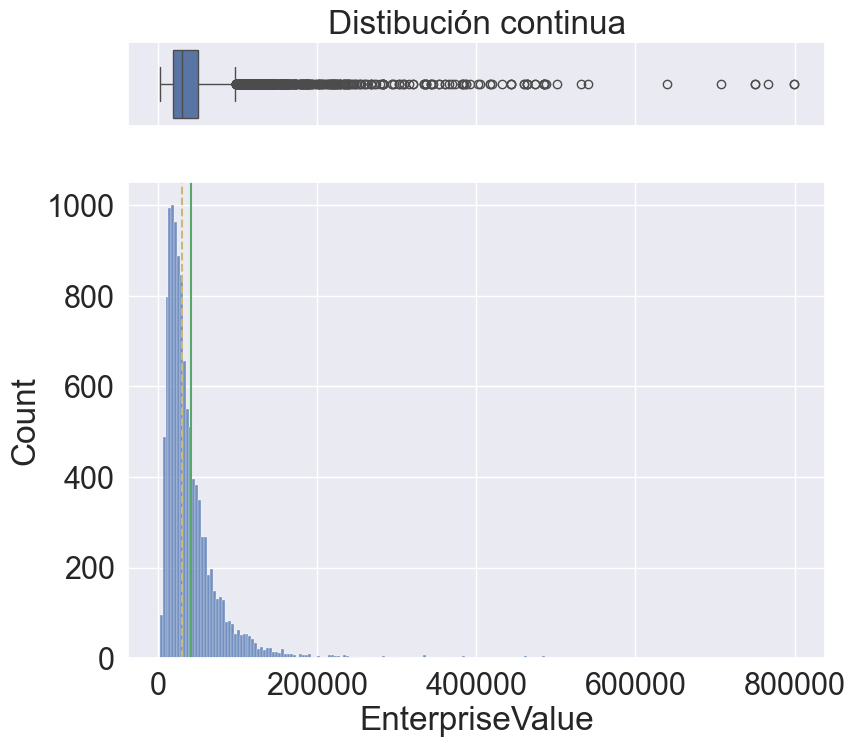

In [32]:
# Graficar
columna_a_graficar = 'EnterpriseValue' # indicar columna para el gráfico
plot(df_imputed[columna_a_graficar])

## Transformaciones

* Transformaciones logarítmicas:

In [33]:
columnas_a_transformar = [ 
    'Volume_Lag1',
    'CapExToRevenue',
    'DebtToEquity',
    'QuarterlyVariance_Lag1',
    'MarketCap',
    'EnterpriseValue'
    ]

df_transformed = transformar_log(
    df_imputed, 
    columnas_a_transformar, 
    calculo_1p=True
    )

# Coeficientes de asimetría actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

TrailingPE                         103.430672
RelativeRevenue                     73.005193
PriceToBook                         49.781784
ReturnOnEquity                      37.218062
CashAndCashEquivalents              36.807889
EnterpriseToEbitda                  35.683074
CurrentDebt                         20.556837
TotalDebt                           16.969607
QuarterlyReturn_Lag1                11.331155
Fcf_QoQ                              8.335656
CapExToRevenue_Log1p                 7.710461
LongTermDebt                         6.287849
CurrentAssets                        5.633388
GrossProfit_TTM                      5.529005
ReturnOnAssets                       5.522634
BasicAverageShares_TTM               5.324528
CurrentLiabilities                   5.069638
NetIncome_TTM                        4.877192
StockholdersEquity                   4.630931
Ebitda_QoQ                           4.541205
RelativeAssets                       4.211234
Revenue_YoY                       

## Tratamiento de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [34]:
# Definir columnas que saltean la "winsorización"
cols_fin_clean = obtener_cols_financieras(incluirTTM=True)

columnas_intactas = cols_fin_clean + [
    # Variables de precio y ratios
    'Close',
    'Open',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    # Otras
    'Date', 
    'Ticker'   
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

In [35]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

In [36]:
# Coeficientes de asimetría luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

FcfToEbitda                     1.784143
RelativeRevenue                 1.706865
RelativeAssets                  1.668236
CapExToRevenue_Log1p            1.622455
ReturnOnEquity                  1.607320
QuarterlyVariance_Lag1_Log1p    1.593672
Ebitda_YoY                      1.559739
ReturnOnAssets                  1.509258
Revenue_YoY                     1.454563
YearsSinceAdded                 1.440526
NetDebtToEbitda                 1.438810
DebtToEquity_Log1p              1.426353
CurrentRatio                    1.329900
CapEx_Acceleration              1.311607
Fcf_YoY                         1.310918
QuarterlyReturn_Lag1            1.290387
Fcf_QoQ                         0.862383
ProfitMargins                   0.851597
OperatingMargins                0.829269
Ebitda_QoQ                      0.573353
EnterpriseValue_Log1p           0.279450
Revenue_QoQ                     0.235846
MarketCovariance_Lag1           0.211532
MarketCap_Log1p                 0.165719
Volume_Lag1_Log1

Cont


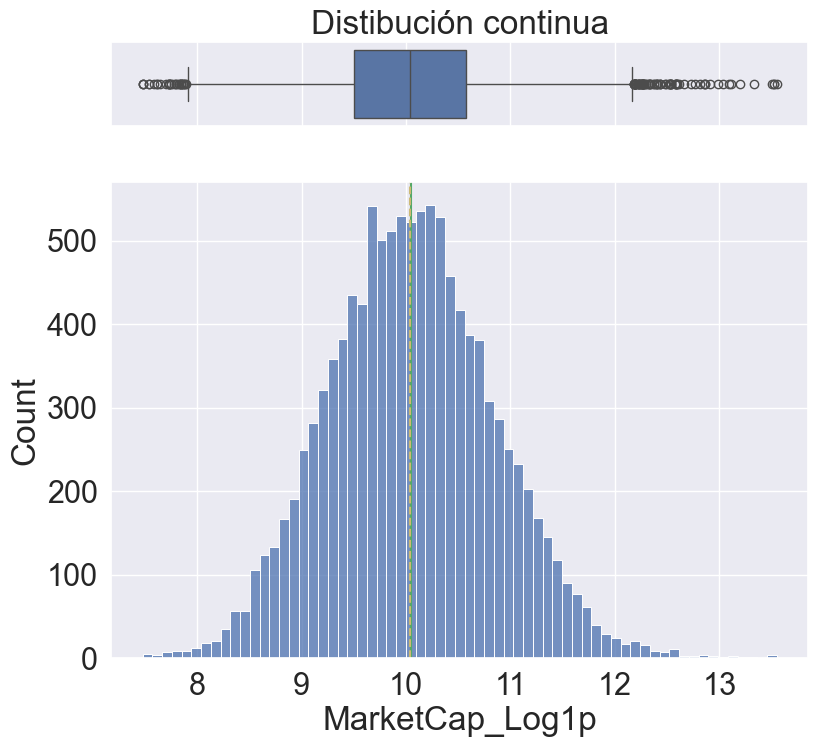

In [37]:
# Visualizar cambios
columna_a_graficar = 'MarketCap_Log1p' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [38]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,11383.0,15.079241,19.651167,0.000000,0.000000,7.000000,24.000000,69.000000
OperatingMargins,11383.0,0.143864,0.062159,-0.069387,0.099042,0.136987,0.178046,0.416310
ProfitMargins,11383.0,0.098244,0.051914,-0.127108,0.063004,0.091270,0.125391,0.315020
ReturnOnEquity,11383.0,0.287394,0.239362,-0.550311,0.131944,0.211997,0.354230,1.025681
ReturnOnAssets,11383.0,0.081046,0.058337,-0.149196,0.041762,0.066544,0.102724,0.286976
CurrentRatio,11383.0,1.541926,0.552946,0.336404,1.169205,1.435008,1.790954,3.659126
Revenue_YoY,11383.0,0.232747,0.633178,-0.906737,-0.168788,0.094828,0.469112,2.389097
Revenue_QoQ,11383.0,0.015992,0.093878,-0.213420,-0.017318,0.007694,0.047767,0.243064
Ebitda_YoY,11383.0,0.511161,1.104922,-1.815358,-0.202101,0.184746,0.807372,3.843102
Ebitda_QoQ,11383.0,0.041498,0.169976,-0.435253,-0.029157,0.002857,0.103437,0.501333


## Concatenación Final

In [39]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11383 entries, 0 to 11382
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   CashAndCashEquivalents           11383 non-null  float64       
 1   CurrentDebt                      11383 non-null  float64       
 2   LongTermDebt                     11383 non-null  float64       
 3   TotalDebt                        11383 non-null  float64       
 4   StockholdersEquity               11383 non-null  float64       
 5   TotalAssets                      11383 non-null  float64       
 6   CurrentAssets                    11383 non-null  float64       
 7   CurrentLiabilities               11383 non-null  float64       
 8   OperatingCashFlow_TTM            11383 non-null  float64       
 9   InvestingCashFlow_TTM            11383 non-null  float64       
 10  FinancingCashFlow_TTM            11383 non-null  float64  

In [40]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")
print(f"Fichero 'clean_data.parquet' guardado en la carpeta {data_folder}")

Fichero 'clean_data.parquet' guardado en la carpeta data
